In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as cx

pd.set_option("display.max_rows", None)         # show all rows
pd.set_option("display.max_columns", None)      # show all columns
pd.set_option("display.width", None)            # auto-detect width (no wrapping cutoff)
pd.set_option("display.max_colwidth", None)     # don't truncate long strings
pd.set_option("display.expand_frame_repr", False)  # keep wide frames on one line in many consoles
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")  # comma + 6 decimals

import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv("../data/dc_parking_data.csv")

In [6]:
df.columns

Index(['OBJECTID', 'TICKET_NUMBER', 'ISSUE_DATE', 'ISSUE_TIME',
       'ISSUING_AGENCY_CODE', 'ISSUING_AGENCY_NAME', 'ISSUING_AGENCY_SHORT',
       'VIOLATION_CODE', 'VIOLATION_PROC_DESC', 'LOCATION', 'PLATE_STATE',
       'VEHICLE_TYPE', 'MULTI_OWNER_NUMBER', 'DISPOSITION_CODE',
       'DISPOSITION_TYPE', 'DISPOSITION_DESC', 'DISPOSITION_DATE',
       'FINE_AMOUNT', 'TOTAL_PAID', 'PENALTY_1', 'PENALTY_2', 'PENALTY_3',
       'PENALTY_4', 'PENALTY_5', 'XCOORD', 'YCOORD', 'LATITUDE', 'LONGITUDE',
       'MAR_ID', 'GIS_LAST_MOD_DTTM', 'ZCTA'],
      dtype='object')

In [7]:
df.head()

,OBJECTID,TICKET_NUMBER,ISSUE_DATE,ISSUE_TIME,ISSUING_AGENCY_CODE,ISSUING_AGENCY_NAME,ISSUING_AGENCY_SHORT,VIOLATION_CODE,VIOLATION_PROC_DESC,LOCATION,PLATE_STATE,VEHICLE_TYPE,MULTI_OWNER_NUMBER,DISPOSITION_CODE,DISPOSITION_TYPE,DISPOSITION_DESC,DISPOSITION_DATE,FINE_AMOUNT,TOTAL_PAID,PENALTY_1,PENALTY_2,PENALTY_3,PENALTY_4,PENALTY_5,XCOORD,YCOORD,LATITUDE,LONGITUDE,MAR_ID,GIS_LAST_MOD_DTTM,ZCTA
0,83861572,287252184,2025-01-01 05:00:00+00:00,314,3,METROPOLITAN POLICE DPT-DISTRICT 3,MPD-3D,P001,PARK ABREAST OF ANOTHER VEHICLE,SS 1400 BLK U STREET NW,,NaN,0.000000,0,Other,NaN,NaN,50,50,0,0,0,0,0,"397,117.190000","138,792.610000",38.917000,-77.033000,"802,845.000000",2025/02/16 15:05:02+00,"20,009.000000"
1,83862192,294619021,2025-01-01 05:00:00+00:00,1350,24,U.S. NATIONAL ZOOLOGICAL POLICE,NZP,P007,PARK IN A BUS ZONE,3131 CONNECTICUT AVE NW,,NaN,0.000000,0,Other,NaN,NaN,100,0,100,0,0,0,0,"395,188.030000","140,377.940000",38.931000,-77.055000,"294,459.000000",2025/02/16 15:05:03+00,"20,008.000000"
2,83862193,294619032,2025-01-01 05:00:00+00:00,1351,24,U.S. NATIONAL ZOOLOGICAL POLICE,NZP,P007,PARK IN A BUS ZONE,3131 CONNECTICUT AVE NW,,NaN,0.000000,0,Other,NaN,NaN,100,0,100,0,0,0,0,"395,188.030000","140,377.940000",38.931000,-77.055000,"294,459.000000",2025/02/16 15:05:03+00,"20,008.000000"
3,83862195,294653833,2025-01-01 05:00:00+00:00,1620,3,METROPOLITAN POLICE DPT-DISTRICT 3,MPD-3D,P003,RESIDENTIAL PERMIT PKING BEYOND LIMIT W/O PERMIT,REAR 1777 T STREET NW,,NaN,0.000000,134,Dismissed,DISM MAKE MISMATCH,2025/01/13 05:00:00+00,50,0,0,0,0,0,0,"396,408.600000","138,659.310000",38.916000,-77.041000,"241,478.000000",2025/02/16 15:05:03+00,"20,009.000000"
4,83862236,295109183,2025-01-01 05:00:00+00:00,2115,1,METROPOLITAN POLICE DPT-DISTRICT 1,MPD-1D,P001,PARK ABREAST OF ANOTHER VEHICLE,NS 700 BLK 7TH ST NE,,NaN,0.000000,106,Dismissed,DISM NOI SUBM LATE,2025/01/23 05:00:00+00,50,0,0,0,0,0,0,"400,332.380000","136,856.050000",38.900000,-76.996000,"800,861.000000",2025/02/16 15:05:03+00,"20,002.000000"


In [8]:
df.describe()

,OBJECTID,TICKET_NUMBER,ISSUE_TIME,ISSUING_AGENCY_CODE,VEHICLE_TYPE,MULTI_OWNER_NUMBER,DISPOSITION_CODE,FINE_AMOUNT,TOTAL_PAID,PENALTY_1,PENALTY_2,PENALTY_3,PENALTY_4,PENALTY_5,XCOORD,YCOORD,LATITUDE,LONGITUDE,MAR_ID,ZCTA
count,"1,027,421.000000","1,027,421.000000","1,027,421.000000","1,027,421.000000",0.000000,"1,027,378.000000","1,027,421.000000","1,027,421.000000","1,027,421.000000","1,027,421.000000","1,027,421.000000","1,027,421.000000","1,027,421.000000","1,027,421.000000","1,019,027.000000","1,019,027.000000","1,019,027.000000","1,019,027.000000","1,019,027.000000","985,930.000000"
mean,"84,474,814.953260","8,084,057,030.970328","1,251.739873",15.005957,NaN,"42,550,817.014384",3.216047,59.707378,20.564124,15.133490,0.000000,0.000000,0.000005,0.000000,"397,893.855759","137,599.438655",38.906261,-77.024314,"787,475.885166","20,011.435283"
std,"347,626.753449","998,939,012.153786",528.519852,2.904774,NaN,"196,202,304.866837",19.706751,48.025541,36.132188,37.170383,0.000000,0.000000,0.002206,0.000000,"2,330.228920","2,304.369308",0.020754,0.026873,"111,005.721096",11.298132
min,"83,855,903.000000","260,541,223.000000",0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"390,147.800000","127,956.750000",38.819000,-77.114000,"-38,388.000000","20,001.000000"
25%,"84,193,026.000000","8,276,250,754.000000",956.000000,15.000000,NaN,0.000000,0.000000,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"396,410.040000","136,474.860000",38.896000,-77.041000,"803,410.000000","20,003.000000"
50%,"84,471,142.000000","8,279,118,540.000000","1,228.000000",15.000000,NaN,0.000000,0.000000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"397,654.880000","137,372.730000",38.904000,-77.027000,"807,447.000000","20,007.000000"
75%,"84,779,351.000000","8,282,627,076.000000","1,619.000000",15.000000,NaN,0.000000,0.000000,100.000000,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"399,140.710000","138,673.040000",38.916000,-77.010000,"811,721.000000","20,018.000000"
max,"85,171,385.000000","9,110,549,700.000000","2,359.000000",80.000000,NaN,"950,789,840.000000",201.000000,"5,000.000000","1,000.000000","5,000.000000",0.000000,0.000000,1.000000,0.000000,"407,817.910000","147,150.300000",38.992000,-76.910000,"914,818.000000","20,037.000000"


In [9]:
df.isna().sum()

OBJECTID                      0
TICKET_NUMBER                 0
ISSUE_DATE                    0
ISSUE_TIME                    0
ISSUING_AGENCY_CODE           0
ISSUING_AGENCY_NAME           0
ISSUING_AGENCY_SHORT          0
VIOLATION_CODE                0
VIOLATION_PROC_DESC         154
LOCATION                      0
PLATE_STATE                   0
VEHICLE_TYPE            1027421
MULTI_OWNER_NUMBER           43
DISPOSITION_CODE              0
DISPOSITION_TYPE              0
DISPOSITION_DESC         994376
DISPOSITION_DATE         994109
FINE_AMOUNT                   0
TOTAL_PAID                    0
PENALTY_1                     0
PENALTY_2                     0
PENALTY_3                     0
PENALTY_4                     0
PENALTY_5                     0
XCOORD                     8394
YCOORD                     8394
LATITUDE                   8394
LONGITUDE                  8394
MAR_ID                     8394
GIS_LAST_MOD_DTTM             0
ZCTA                      41491
dtype: i

## EDA Plan

### GroupBys
- Month
- Quarter
- Day of Week
- Time of Day bands
- Issuing Agency

### Location
- Build a graph of lat/long w/ frequencies?
- Map w/ Zip codes

In [10]:
df["ISSUE_DATE"] = pd.to_datetime(df["ISSUE_DATE"])

monthly_counts = (
    df.groupby(df["ISSUE_DATE"].dt.to_period("M"))
      .size()
      .reset_index(name="row_count")
)

monthly_counts["ISSUE_DATE"] = monthly_counts["ISSUE_DATE"].astype(str)
print(monthly_counts)

   ISSUE_DATE  row_count
0     2025-01      63356
1     2025-02      74096
2     2025-03     100772
3     2025-04     105236
4     2025-05      96284
5     2025-06      88868
6     2025-07      97041
7     2025-08      46514
8     2025-09      95581
9     2025-10     102650
10    2025-11      72479
11    2025-12      84544


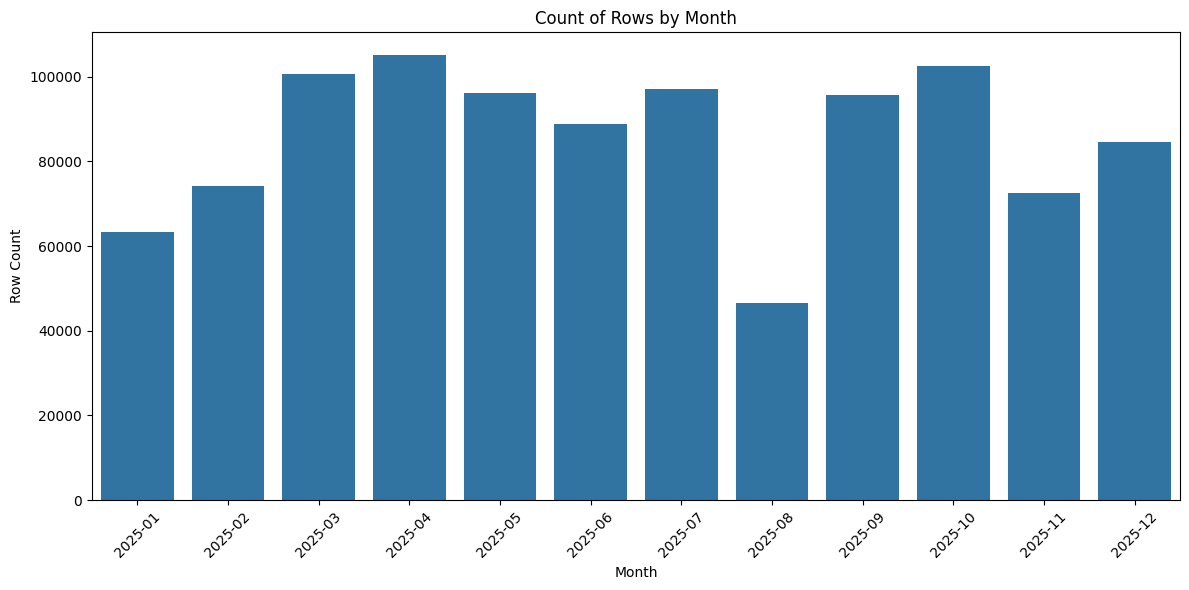

In [11]:
plt.figure(figsize=(12, 6))
sns.barplot(data=monthly_counts, x="ISSUE_DATE", y="row_count")

plt.title("Count of Rows by Month")
plt.xlabel("Month")
plt.ylabel("Row Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

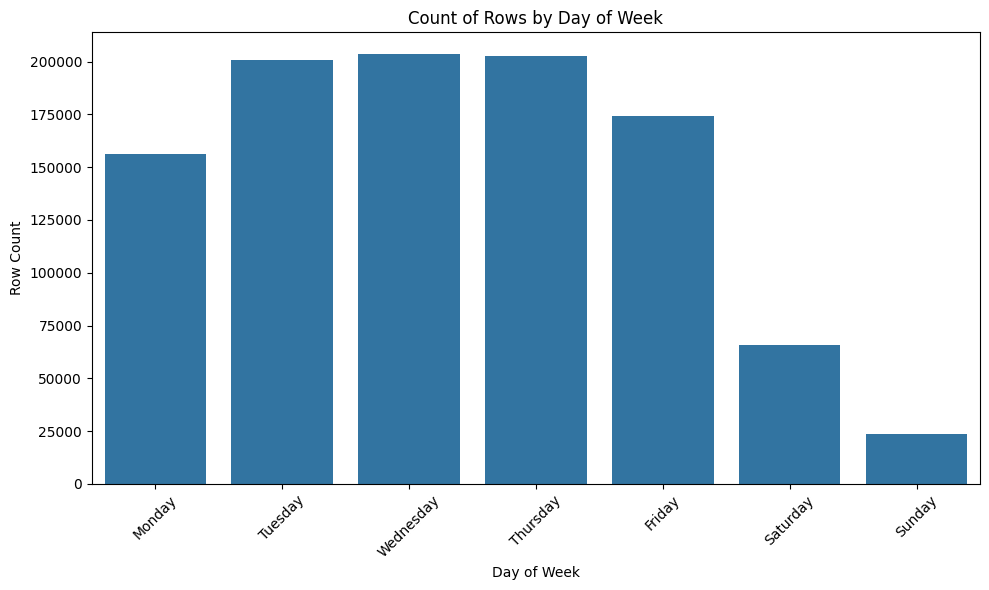

In [12]:
dow_counts = (
    df.assign(day_of_week=df["ISSUE_DATE"].dt.day_name())
      .groupby("day_of_week")
      .size()
      .reset_index(name="row_count")
)

day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

dow_counts["day_of_week"] = pd.Categorical(
    dow_counts["day_of_week"],
    categories=day_order,
    ordered=True
)

dow_counts = dow_counts.sort_values("day_of_week")

plt.figure(figsize=(10, 6))
sns.barplot(data=dow_counts, x="day_of_week", y="row_count")

plt.title("Count of Rows by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Row Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

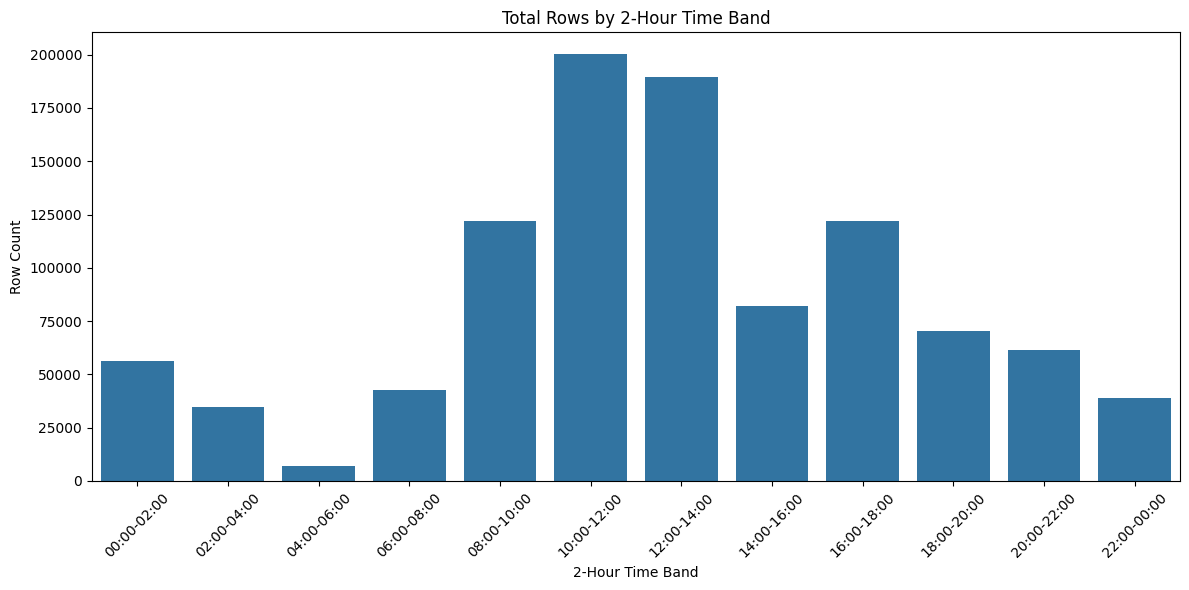

In [13]:
# make sure ISSUE_TIME is a 4-digit string like 1350 -> "1350"
df["ISSUE_TIME"] = df["ISSUE_TIME"].astype(str).str.zfill(4)

# split into hour/minute
df["issue_hour"] = df["ISSUE_TIME"].str[:2].astype(int)
df["issue_minute"] = df["ISSUE_TIME"].str[2:4].astype(int)

# optional: drop invalid times
df = df[
    (df["issue_hour"].between(0, 23)) &
    (df["issue_minute"].between(0, 59))
].copy()

# create 2-hour bins
df["time_band_start"] = (df["issue_hour"] // 2) * 2
df["time_band_label"] = (
    df["time_band_start"].astype(str).str.zfill(2)
    + ":00-"
    + (df["time_band_start"] + 2).mod(24).astype(str).str.zfill(2)
    + ":00"
)

# keep bands in the right order
band_order = [f"{str(h).zfill(2)}:00-{str((h+2)%24).zfill(2)}:00" for h in range(0, 24, 2)]

time_band_counts = (
    df.groupby("time_band_label")
      .size()
      .reset_index(name="row_count")
)

time_band_counts["time_band_label"] = pd.Categorical(
    time_band_counts["time_band_label"],
    categories=band_order,
    ordered=True
)

time_band_counts = time_band_counts.sort_values("time_band_label")

plt.figure(figsize=(12, 6))
sns.barplot(data=time_band_counts, x="time_band_label", y="row_count")

plt.title("Total Rows by 2-Hour Time Band")
plt.xlabel("2-Hour Time Band")
plt.ylabel("Row Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

       ZCTA  row_count
0   20001.0     132036
1   20002.0     107251
2   20003.0      65734
3   20004.0      43566
4   20005.0      59553
5   20006.0      40848
6   20007.0      48463
7   20008.0      27439
8   20009.0     102862
9   20010.0      30114
10  20011.0      36326
11  20012.0       6907
12  20015.0       6041
13  20016.0      16522
14  20017.0       9991
15  20018.0      11332
16  20019.0      26510
17  20020.0      21078
18  20024.0      75075
19  20032.0       6235
20  20036.0      55671
21  20037.0      56375


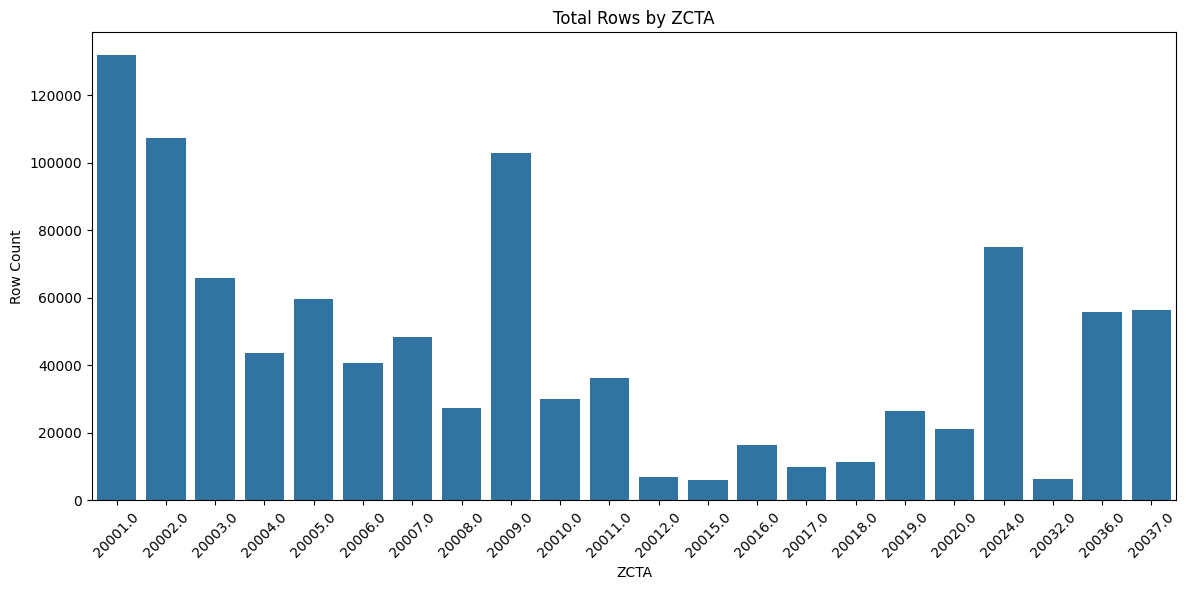

In [14]:
zip_counts = (
    df.groupby(df["ZCTA"])
      .size()
      .reset_index(name="row_count")
)

zip_counts["ZCTA"] = zip_counts["ZCTA"].astype(str)
print(zip_counts)

plt.figure(figsize=(12, 6))
sns.barplot(data=zip_counts, x="ZCTA", y="row_count")

plt.title("Total Rows by ZCTA")
plt.xlabel("ZCTA")
plt.ylabel("Row Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
df.head()

,OBJECTID,TICKET_NUMBER,ISSUE_DATE,ISSUE_TIME,ISSUING_AGENCY_CODE,ISSUING_AGENCY_NAME,ISSUING_AGENCY_SHORT,VIOLATION_CODE,VIOLATION_PROC_DESC,LOCATION,PLATE_STATE,VEHICLE_TYPE,MULTI_OWNER_NUMBER,DISPOSITION_CODE,DISPOSITION_TYPE,DISPOSITION_DESC,DISPOSITION_DATE,FINE_AMOUNT,TOTAL_PAID,PENALTY_1,PENALTY_2,PENALTY_3,PENALTY_4,PENALTY_5,XCOORD,YCOORD,LATITUDE,LONGITUDE,MAR_ID,GIS_LAST_MOD_DTTM,ZCTA,issue_hour,issue_minute,time_band_start,time_band_label
0,83861572,287252184,2025-01-01 05:00:00+00:00,0314,3,METROPOLITAN POLICE DPT-DISTRICT 3,MPD-3D,P001,PARK ABREAST OF ANOTHER VEHICLE,SS 1400 BLK U STREET NW,,NaN,0.000000,0,Other,NaN,NaN,50,50,0,0,0,0,0,"397,117.190000","138,792.610000",38.917000,-77.033000,"802,845.000000",2025/02/16 15:05:02+00,"20,009.000000",3,14,2,02:00-04:00
1,83862192,294619021,2025-01-01 05:00:00+00:00,1350,24,U.S. NATIONAL ZOOLOGICAL POLICE,NZP,P007,PARK IN A BUS ZONE,3131 CONNECTICUT AVE NW,,NaN,0.000000,0,Other,NaN,NaN,100,0,100,0,0,0,0,"395,188.030000","140,377.940000",38.931000,-77.055000,"294,459.000000",2025/02/16 15:05:03+00,"20,008.000000",13,50,12,12:00-14:00
2,83862193,294619032,2025-01-01 05:00:00+00:00,1351,24,U.S. NATIONAL ZOOLOGICAL POLICE,NZP,P007,PARK IN A BUS ZONE,3131 CONNECTICUT AVE NW,,NaN,0.000000,0,Other,NaN,NaN,100,0,100,0,0,0,0,"395,188.030000","140,377.940000",38.931000,-77.055000,"294,459.000000",2025/02/16 15:05:03+00,"20,008.000000",13,51,12,12:00-14:00
3,83862195,294653833,2025-01-01 05:00:00+00:00,1620,3,METROPOLITAN POLICE DPT-DISTRICT 3,MPD-3D,P003,RESIDENTIAL PERMIT PKING BEYOND LIMIT W/O PERMIT,REAR 1777 T STREET NW,,NaN,0.000000,134,Dismissed,DISM MAKE MISMATCH,2025/01/13 05:00:00+00,50,0,0,0,0,0,0,"396,408.600000","138,659.310000",38.916000,-77.041000,"241,478.000000",2025/02/16 15:05:03+00,"20,009.000000",16,20,16,16:00-18:00
4,83862236,295109183,2025-01-01 05:00:00+00:00,2115,1,METROPOLITAN POLICE DPT-DISTRICT 1,MPD-1D,P001,PARK ABREAST OF ANOTHER VEHICLE,NS 700 BLK 7TH ST NE,,NaN,0.000000,106,Dismissed,DISM NOI SUBM LATE,2025/01/23 05:00:00+00,50,0,0,0,0,0,0,"400,332.380000","136,856.050000",38.900000,-76.996000,"800,861.000000",2025/02/16 15:05:03+00,"20,002.000000",21,15,20,20:00-22:00


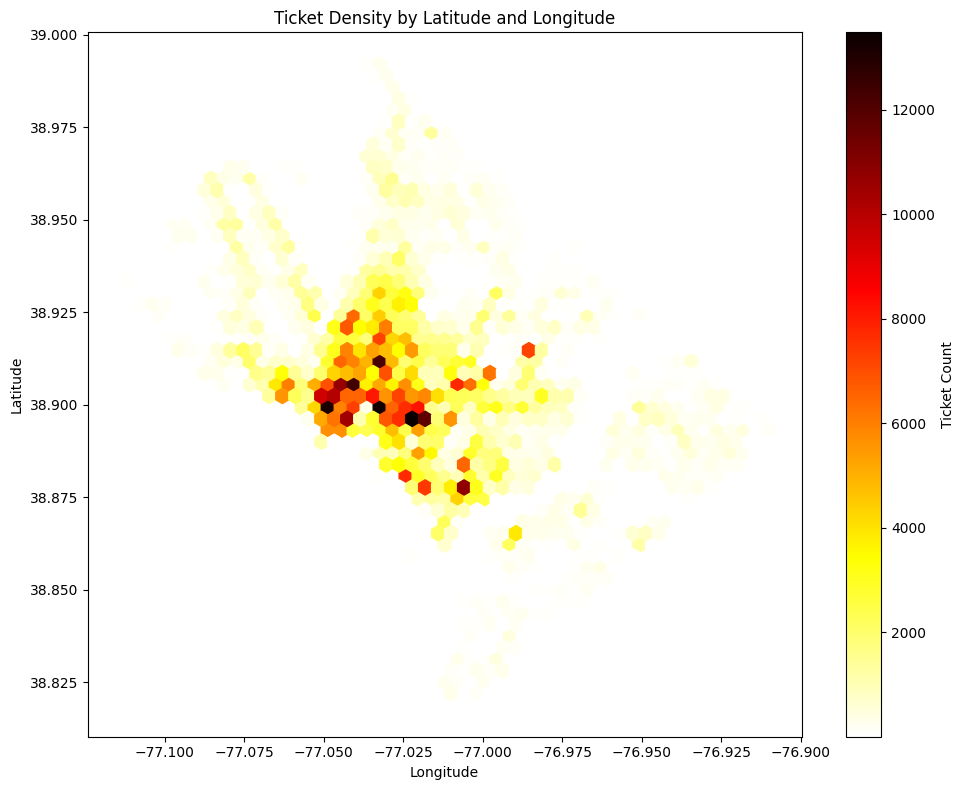

In [20]:
# make sure latitude/longitude are numeric
df["LATITUDE"] = pd.to_numeric(df["LATITUDE"], errors="coerce")
df["LONGITUDE"] = pd.to_numeric(df["LONGITUDE"], errors="coerce")

# keep valid coords only
plot_df = df.dropna(subset=["LATITUDE", "LONGITUDE"]).copy()

plt.figure(figsize=(10, 8))
hb = plt.hexbin(
    plot_df["LONGITUDE"],
    plot_df["LATITUDE"],
    gridsize=50,
    cmap="hot_r",
    mincnt=1
)

plt.colorbar(hb, label="Ticket Count")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Ticket Density by Latitude and Longitude")
plt.tight_layout()
plt.show()

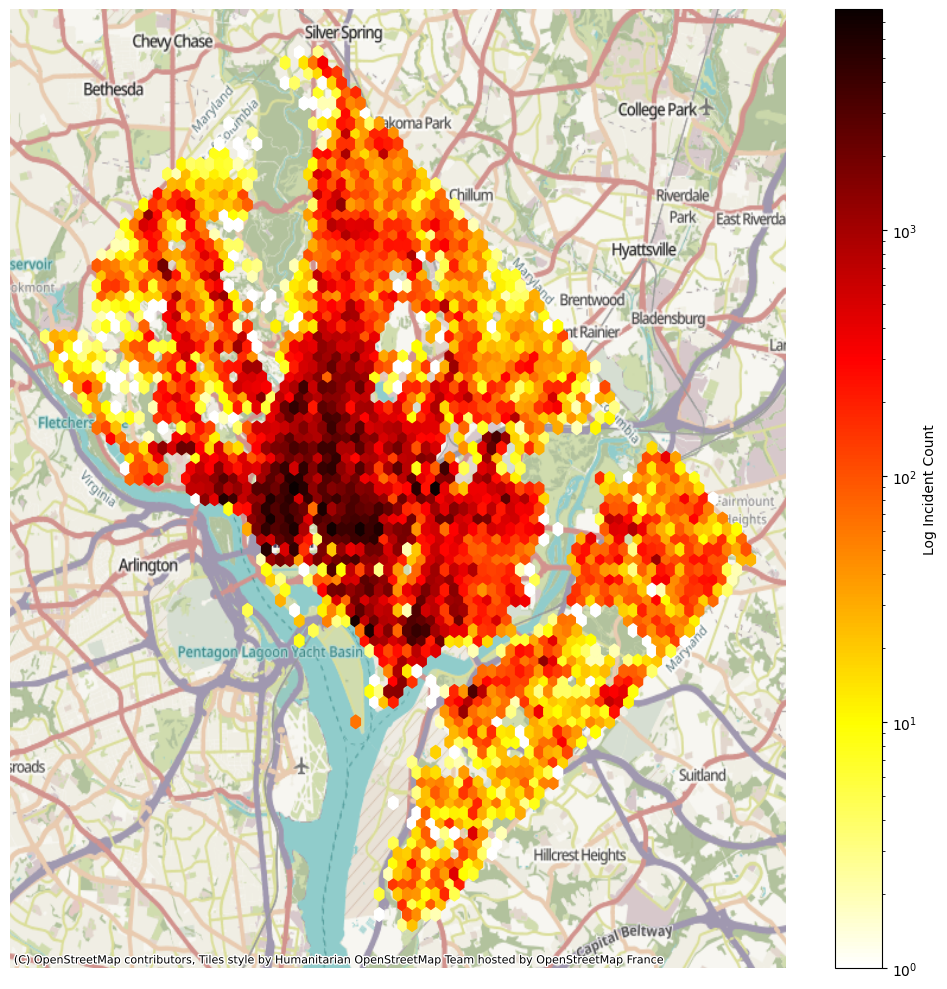

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import contextily as cx
import geopandas as gpd

df["LATITUDE"] = pd.to_numeric(df["LATITUDE"], errors="coerce")
df["LONGITUDE"] = pd.to_numeric(df["LONGITUDE"], errors="coerce")

plot_df = df.dropna(subset=["LATITUDE", "LONGITUDE"]).copy()

gdf = gpd.GeoDataFrame(
    plot_df,
    geometry=gpd.points_from_xy(plot_df["LONGITUDE"], plot_df["LATITUDE"]),
    crs="EPSG:4326"
).to_crs(epsg=3857)

# transparent red -> solid red
transparent_reds = mcolors.LinearSegmentedColormap.from_list(
    "transparent_reds",
    [
        (1, 0, 0, 0.0),   # transparent red
        (1, 0, 0, 0.9)    # solid red
    ]
)

fig, ax = plt.subplots(figsize=(10, 10))

hb = ax.hexbin(
    gdf.geometry.x,
    gdf.geometry.y,
    gridsize=75,
    cmap="hot_r",
    mincnt=1,
    bins="log"
)

cx.add_basemap(ax)
ax.set_axis_off()

cb = plt.colorbar(hb, ax=ax)
cb.set_label("Log Incident Count")

plt.tight_layout()
plt.show()

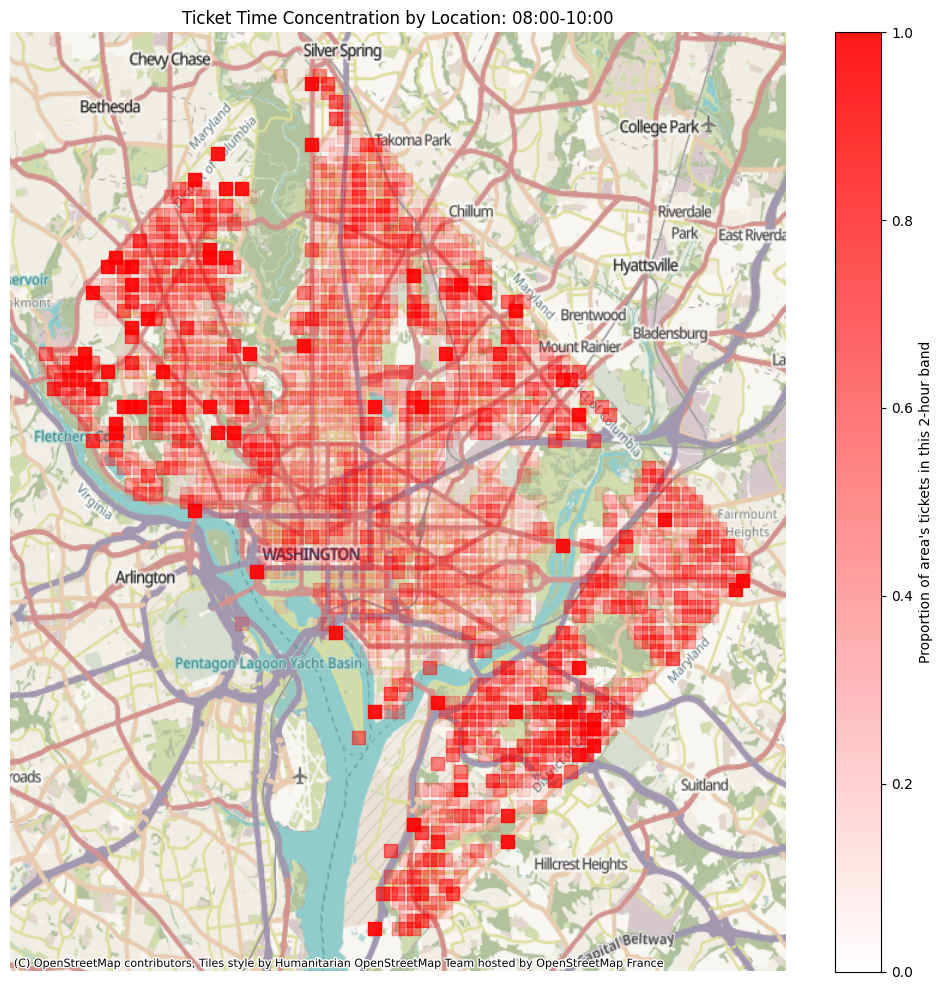

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import contextily as cx
import geopandas as gpd

# -----------------------------
# 1. clean lat/lon and time
# -----------------------------
df["LATITUDE"] = pd.to_numeric(df["LATITUDE"], errors="coerce")
df["LONGITUDE"] = pd.to_numeric(df["LONGITUDE"], errors="coerce")
df["ISSUE_TIME"] = df["ISSUE_TIME"].astype(str).str.zfill(4)

df["issue_hour"] = pd.to_numeric(df["ISSUE_TIME"].str[:2], errors="coerce")
df["issue_minute"] = pd.to_numeric(df["ISSUE_TIME"].str[2:4], errors="coerce")

plot_df = df.dropna(subset=["LATITUDE", "LONGITUDE", "issue_hour", "issue_minute"]).copy()
plot_df = plot_df[
    plot_df["issue_hour"].between(0, 23) &
    plot_df["issue_minute"].between(0, 59)
].copy()

# 2-hour band start: 0,2,4,...,22
plot_df["time_band_start"] = (plot_df["issue_hour"] // 2) * 2

# -----------------------------
# 2. project to web mercator
# -----------------------------
gdf = gpd.GeoDataFrame(
    plot_df,
    geometry=gpd.points_from_xy(plot_df["LONGITUDE"], plot_df["LATITUDE"]),
    crs="EPSG:4326"
).to_crs(epsg=3857)

gdf["x"] = gdf.geometry.x
gdf["y"] = gdf.geometry.y

# -----------------------------
# 3. make spatial grid
# -----------------------------
grid_size = 250  # meters; try 150, 250, 400 depending on desired smoothness

xmin, xmax = gdf["x"].min(), gdf["x"].max()
ymin, ymax = gdf["y"].min(), gdf["y"].max()

x_edges = np.arange(xmin, xmax + grid_size, grid_size)
y_edges = np.arange(ymin, ymax + grid_size, grid_size)

gdf["x_bin"] = pd.cut(gdf["x"], bins=x_edges, include_lowest=True)
gdf["y_bin"] = pd.cut(gdf["y"], bins=y_edges, include_lowest=True)

# optional: drop points that somehow fall outside bins
gdf = gdf.dropna(subset=["x_bin", "y_bin"]).copy()

# -----------------------------
# 4. counts by location + time band
# -----------------------------
counts = (
    gdf.groupby(["x_bin", "y_bin", "time_band_start"])
       .size()
       .reset_index(name="ticket_count")
)

# total tickets in each location cell across all time bands
cell_totals = (
    gdf.groupby(["x_bin", "y_bin"])
       .size()
       .reset_index(name="cell_total")
)

counts = counts.merge(cell_totals, on=["x_bin", "y_bin"], how="left")
counts["prop_in_cell"] = counts["ticket_count"] / counts["cell_total"]

# -----------------------------
# 5. convert bins to cell centers for plotting
# -----------------------------
counts["x_center"] = counts["x_bin"].apply(lambda b: b.mid)
counts["y_center"] = counts["y_bin"].apply(lambda b: b.mid)

# -----------------------------
# 6. choose one time band to plot
# -----------------------------

selected_band = 8  # example: 8 means 08:00-10:00

plot_band = counts[counts["time_band_start"] == selected_band].copy()

# transparent red colormap
transparent_reds = mcolors.LinearSegmentedColormap.from_list(
    "transparent_reds",
    [
        (1.0, 0.0, 0.0, 0.0),
        (1.0, 0.0, 0.0, 0.9)
    ]
)

# -----------------------------
# 7. plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 10))

sc = ax.scatter(
    plot_band["x_center"],
    plot_band["y_center"],
    c=plot_band["prop_in_cell"],
    cmap=transparent_reds,
    s=grid_size * 0.35,   # tune for appearance
    marker="s"
)

cx.add_basemap(ax)
ax.set_axis_off()

cb = plt.colorbar(sc, ax=ax)
cb.set_label("Proportion of area's tickets in this 2-hour band")

label = f"{selected_band:02d}:00-{(selected_band + 2) % 24:02d}:00"
ax.set_title(f"Ticket Time Concentration by Location: {label}")

plt.tight_layout()
plt.show()

In [ ]:
from ipywidgets import interact, IntSlider
import matplotlib.pyplot as plt

bands = list(range(0, 24, 2))

@interact(selected_band=IntSlider(min=0, max=22, step=2, value=8))
def plot_band_map(selected_band):
    plot_band = counts[counts["time_band_start"] == selected_band].copy()

    fig, ax = plt.subplots(figsize=(10, 10))

    sc = ax.scatter(
        plot_band["x_center"],
        plot_band["y_center"],
        c=plot_band["prop_in_cell"],
        cmap=transparent_reds,
        s=grid_size * 0.35,
        marker="s",
        vmin=0,
        vmax=counts["prop_in_cell"].max()
    )

    cx.add_basemap(ax)
    ax.set_axis_off()

    cb = plt.colorbar(sc, ax=ax)
    cb.set_label("Proportion of area's tickets in this 2-hour band")

    label = f"{selected_band:02d}:00-{(selected_band + 2) % 24:02d}:00"
    ax.set_title(f"Ticket Time Concentration by Location: {label}")

    plt.tight_layout()
    plt.show()

interactive(children=(IntSlider(value=8, description='selected_band', max=22, step=2), Output()), _dom_classes…

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import contextily as cx
import geopandas as gpd
import imageio.v2 as imageio
import os

# -----------------------------
# 1. prep data
# -----------------------------
df["LATITUDE"] = pd.to_numeric(df["LATITUDE"], errors="coerce")
df["LONGITUDE"] = pd.to_numeric(df["LONGITUDE"], errors="coerce")
df["ISSUE_TIME"] = df["ISSUE_TIME"].astype(str).str.zfill(4)

df["issue_hour"] = pd.to_numeric(df["ISSUE_TIME"].str[:2], errors="coerce")
df["issue_minute"] = pd.to_numeric(df["ISSUE_TIME"].str[2:4], errors="coerce")

plot_df = df.dropna(subset=["LATITUDE", "LONGITUDE", "issue_hour", "issue_minute"]).copy()
plot_df = plot_df[
    plot_df["issue_hour"].between(0, 23) &
    plot_df["issue_minute"].between(0, 59)
].copy()

df["time_band_start"] = (df["issue_hour"] // 2) * 2
plot_df["time_band_start"] = (plot_df["issue_hour"] // 2) * 2

# -----------------------------
# 2. project coordinates
# -----------------------------
gdf = gpd.GeoDataFrame(
    plot_df,
    geometry=gpd.points_from_xy(plot_df["LONGITUDE"], plot_df["LATITUDE"]),
    crs="EPSG:4326"
).to_crs(epsg=3857)

gdf["x"] = gdf.geometry.x
gdf["y"] = gdf.geometry.y

# -----------------------------
# 3. spatial grid
# -----------------------------
grid_size = 250  # meters

xmin, xmax = gdf["x"].min(), gdf["x"].max()
ymin, ymax = gdf["y"].min(), gdf["y"].max()

x_edges = np.arange(xmin, xmax + grid_size, grid_size)
y_edges = np.arange(ymin, ymax + grid_size, grid_size)

gdf["x_bin"] = pd.cut(gdf["x"], bins=x_edges, include_lowest=True)
gdf["y_bin"] = pd.cut(gdf["y"], bins=y_edges, include_lowest=True)

gdf = gdf.dropna(subset=["x_bin", "y_bin"]).copy()

# -----------------------------
# 4. counts and proportions
# -----------------------------
counts = (
    gdf.groupby(["x_bin", "y_bin", "time_band_start"])
       .size()
       .reset_index(name="ticket_count")
)

cell_totals = (
    gdf.groupby(["x_bin", "y_bin"])
       .size()
       .reset_index(name="cell_total")
)

counts = counts.merge(cell_totals, on=["x_bin", "y_bin"], how="left")

# optional: suppress sparse cells
counts = counts[counts["cell_total"] >= 20].copy()

counts["prop_in_cell"] = counts["ticket_count"] / counts["cell_total"]
counts["x_center"] = counts["x_bin"].apply(lambda b: b.mid)
counts["y_center"] = counts["y_bin"].apply(lambda b: b.mid)

# -----------------------------
# 5. colormap
# -----------------------------
transparent_reds = mcolors.LinearSegmentedColormap.from_list(
    "transparent_reds",
    [
        (1.0, 0.0, 0.0, 0.0),
        (1.0, 0.0, 0.0, 0.95)
    ]
)

# fixed color scale across frames
vmin = 0
vmax = counts["prop_in_cell"].max()

# map extent fixed across all frames
xlim = (xmin, xmax)
ylim = (ymin, ymax)

# -----------------------------
# 6. generate frames
# -----------------------------
os.makedirs("gif_frames", exist_ok=True)
frame_paths = []

for selected_band in range(0, 24, 2):
    band_df = counts[counts["time_band_start"] == selected_band].copy()

    fig, ax = plt.subplots(figsize=(10, 10))

    sc = ax.scatter(
        band_df["x_center"],
        band_df["y_center"],
        c=band_df["prop_in_cell"],
        cmap=transparent_reds,
        s=grid_size * 0.35,
        marker="s",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    cx.add_basemap(ax)

    ax.set_axis_off()

    label = f"{selected_band:02d}:00-{(selected_band + 2) % 24:02d}:00"
    ax.set_title(
        f"Share of Local Tickets Occurring in Time Band\n{label}",
        fontsize=14
    )

    cb = plt.colorbar(sc, ax=ax, fraction=0.035, pad=0.02)
    cb.set_label("Proportion of area's tickets in this 2-hour band")

    frame_path = f"gif_frames/frame_{selected_band:02d}.png"
    plt.tight_layout()
    plt.savefig(frame_path, dpi=180, bbox_inches="tight")
    plt.close()

    frame_paths.append(frame_path)

# -----------------------------
# 7. stitch into animated gif
# -----------------------------
images = [imageio.imread(path) for path in frame_paths]
imageio.mimsave("tickets_by_time_band.gif", images, duration=4.0, loop=0)

print("Saved GIF to tickets_by_time_band.gif")

Saved GIF to tickets_by_time_band.gif
